Raw observation shape: (210, 160, 3)


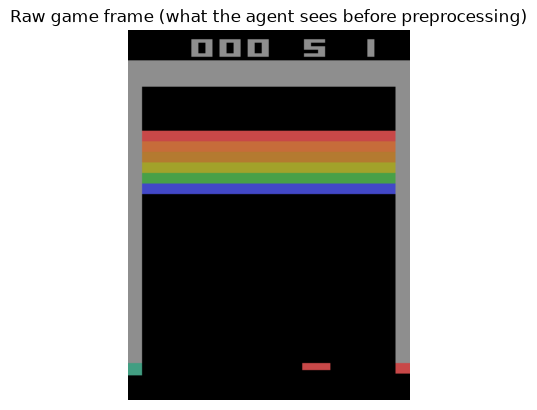

In [1]:
# Cell 1: verify Gymnasium + see what raw pixels look like
import gymnasium as gym
import ale_py
import matplotlib.pyplot as plt

gym.register_envs(ale_py)  # needed in newer gymnasium/ale_py versions

env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
obs, info = env.reset()

print("Raw observation shape:", obs.shape)
plt.imshow(obs)
plt.title("Raw game frame (what the agent sees before preprocessing)")
plt.axis("off")
plt.show()

Stacked shape: (4, 84, 84)


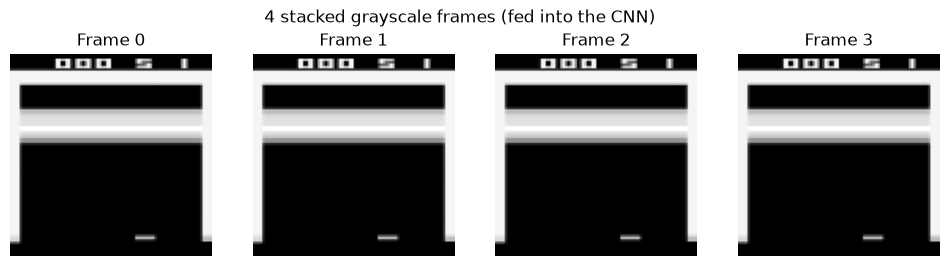

In [2]:
# Cell 2: test the preprocessing pipeline on real frames
import sys
sys.path.append("../src")
from preprocess import FrameStacker

stacker = FrameStacker(k=4, size=84)
obs, info = env.reset()
stacked = stacker.reset(obs)

print("Stacked shape:", stacked.shape)  # should be (4, 84, 84)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(stacked[i], cmap="gray")
    ax.set_title(f"Frame {i}")
    ax.axis("off")
plt.suptitle("4 stacked grayscale frames (fed into the CNN)")
plt.show()

In [3]:
# Cell 3: test the DQN network with a dummy input
import torch
sys.path.append("../src")
from model import DQN

n_actions = env.action_space.n
print("Number of actions in Breakout:", n_actions)

model = DQN(n_actions=n_actions)
dummy_input = torch.tensor(stacked).unsqueeze(0)  # add batch dimension -> (1, 4, 84, 84)
output = model(dummy_input)

print("Q-values output shape:", output.shape)
print("Q-values:", output)

Number of actions in Breakout: 4
Q-values output shape: torch.Size([1, 4])
Q-values: tensor([[-0.0195, -0.0196, -0.0273,  0.0158]], grad_fn=<AddmmBackward0>)


In [4]:
# Cell 4: test the agent - fill buffer with a few random steps, then train once
from agent import DQNAgent

agent = DQNAgent(n_actions=n_actions, device="cpu")

state = stacker.reset(env.reset()[0])
for _ in range(50):
    action = agent.select_action(state, epsilon=1.0)  # fully random for this test
    obs, reward, terminated, truncated, info = env.step(action)
    next_state = stacker.step(obs)
    agent.buffer.push(state, action, reward, next_state, terminated or truncated)
    state = next_state
    if terminated or truncated:
        state = stacker.reset(env.reset()[0])

print("Buffer size:", len(agent.buffer))
loss = agent.train_step(batch_size=32)
print("Training step loss:", loss)

Buffer size: 50
Training step loss: 0.00046351266792044044
